In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pickle
import json

In [3]:
parent_path = '..'

In [4]:
# Load Model
model = tf.keras.models.load_model(f'{parent_path}/models/best_model.h5')

In [5]:
# Load test data
test_data = np.load(f'{parent_path}/data/processed/test_data.npz')
X_test = test_data['X'] 
y_test = test_data['y']

In [6]:
X_test.shape, y_test.shape

((746, 224, 224, 3), (746,))

In [7]:
# Get Prediction
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step


In [12]:
y_pred_proba[0],y_pred[0], y_test[0]

(array([1.0250408e-08, 1.7419362e-10, 1.3436302e-07, 1.8141387e-09,
        9.3240593e-10, 6.1281571e-09, 9.9989128e-01, 1.2303910e-09,
        1.0568677e-07, 2.5328653e-09, 5.5586440e-07, 8.9098599e-08,
        1.5624029e-06, 1.9788187e-09, 2.1991858e-05, 2.2484508e-06,
        2.4833881e-08, 1.3331697e-06, 9.3583612e-09, 1.5059400e-09,
        5.6586267e-11, 1.7608273e-09, 8.0517028e-05, 1.1970035e-07],
       dtype=float32),
 np.int64(6),
 np.int64(6))

In [13]:
# Calculate metrics
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9973


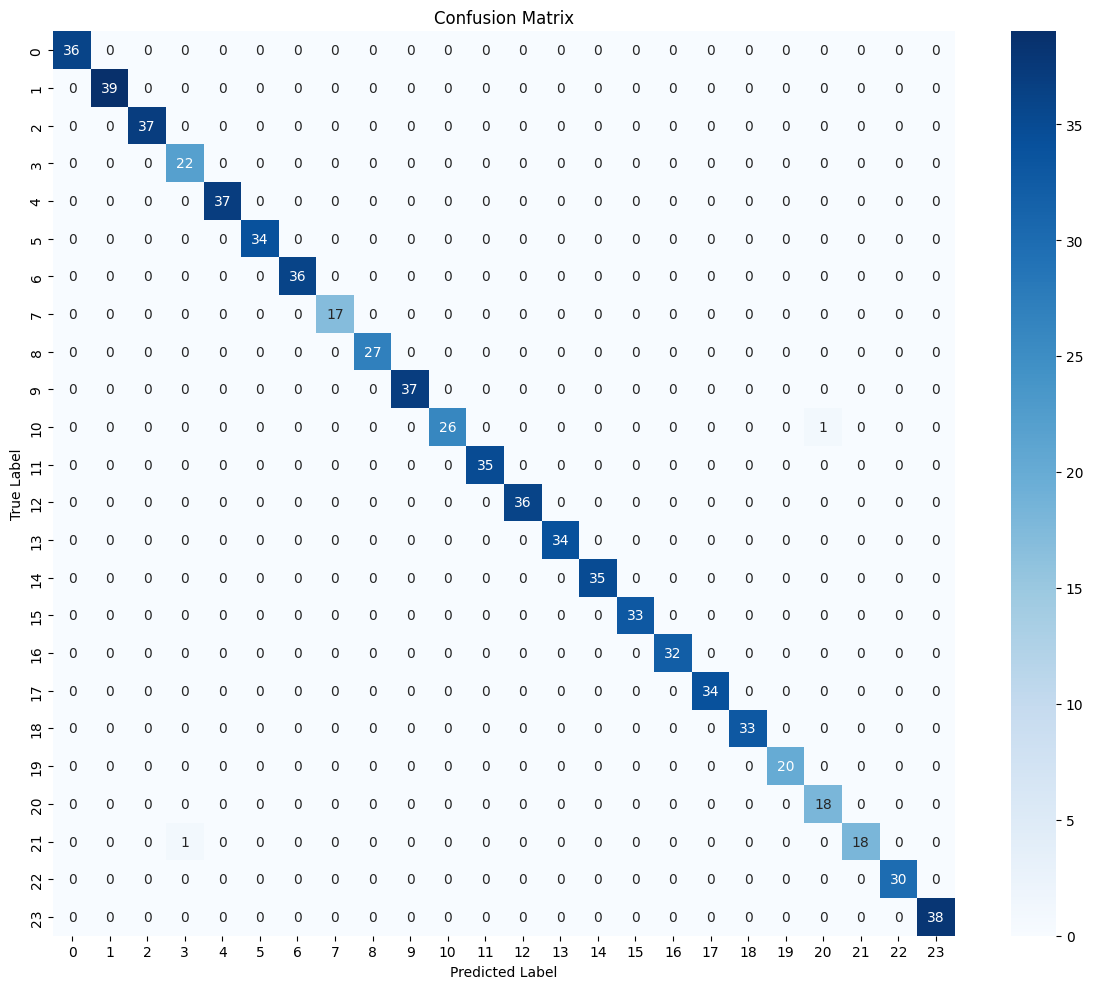

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{parent_path}/results/confusion_matrix.png', dpi=300)
plt.show()
plt.close()

In [16]:
# Classification Report
with open(f'{parent_path}/data/processed/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)


              precision    recall  f1-score   support

           A       1.00      1.00      1.00        36
           B       1.00      1.00      1.00        39
           C       1.00      1.00      1.00        37
           D       0.96      1.00      0.98        22
           E       1.00      1.00      1.00        37
           F       1.00      1.00      1.00        34
           G       1.00      1.00      1.00        36
           H       1.00      1.00      1.00        17
           I       1.00      1.00      1.00        27
           K       1.00      1.00      1.00        37
           L       1.00      0.96      0.98        27
           M       1.00      1.00      1.00        35
           N       1.00      1.00      1.00        36
           O       1.00      1.00      1.00        34
           P       1.00      1.00      1.00        35
           Q       1.00      1.00      1.00        33
           R       1.00      1.00      1.00        32
           S       1.00    

In [ ]:
with open(f'{parent_path}results/classification_report.txt', 'w') as f:
    f.write(report)

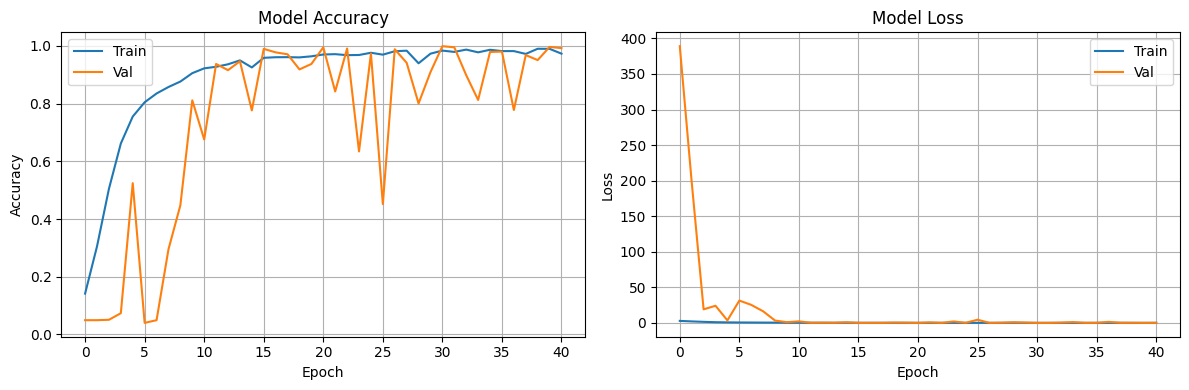

In [25]:
with open(f'{parent_path}/results/training_history.json', 'r') as f:
    history = json.load(f)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f'{parent_path}/results/training_curves.png', dpi=300)
plt.show()
plt.close()